In [1]:
import math
import random
import torch
import time
import matplotlib.pyplot as plt
import numpy as np

In [2]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data=data
        self.grad=0.0
        self._backward= lambda: None
        self._prev=set(_children)
        self._op=_op
        self.label=label
        
    def __repr__(self):
        return f"Value(data = {self.data})"
        
    def __add__(self, other):
        other=other if isinstance (other, Value) else Value(other)
        out=Value(self.data+other.data, (self, other),'+')

        def _backward():
            self.grad+=1.0*out.grad
            other.grad+=1.0*out.grad
        out._backward=_backward
        
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward

        return out

    def __neg__(self): 
        return self * -1

    def __sub__(self, other):
        return self+(-other)
    
    def __mul__(self, other):
        other=other if isinstance (other, Value) else Value(other)
        out=Value(self.data*other.data, (self, other),'*')
        
        def _backward():
            self.grad+=other.data*out.grad
            other.grad+=self.data*out.grad
        out._backward=_backward
        
        return out
    
    def __radd__(self, other): # other + self
        return self + other
    
    def __rmul__(self, other):
        return self*other

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __rtruediv__(self, other): # other / self
        return other * self**-1

    def log(self):
        out=Value(math.log(self.data), (self, ), "log")

        def _backward():
            self.grad+=(1/self.data)*out.grad
        out._backward=_backward

        return out

    def exp(self):
        out = Value(math.exp(self.data), (self,), 'e^x')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        
        return out
    
    def backward(self):
        topo=[]
        visited=set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad=1.0

        for node in reversed(topo):
            node._backward()

    #Activation Functions
    def tanh(self):
        x=self.data
        t=(math.exp(2*x)-1)/(math.exp(2*x)+1)
        out=Value(t, (self,), 'tanh')

        def _backward():
            self.grad+=(1-t**2)*out.grad
        out._backward=_backward

        return out

    def sigmoid(self):
        x=self.data
        sig=1/(1+(math.exp(-x)))
        out=Value(sig, (self,), 'sigmoid')

        def _backward():
            self.grad+=(sig*(1-sig))*out.grad
        out._backward=_backward

        return out

    def leakyReLU(self):
        out=Value(0.01*x if self.data<=0 else self.data, (self,), 'leaky ReLU')

        def _backward():
            self.grad+=(0.01 if self.data<0 else 1)*out.grad
        out._backward=_backward

        return out
    
    def ReLU(self):
        out=Value(0 if self.data<=0 else self.data, (self,), 'ReLU')

        def _backward():
            self.grad+=(self.data>0)*out.grad
        out._backward=_backward

        return out

In [3]:
def trace(root):
    nodes, edges=set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

In [4]:
#Graphviz API
from graphviz import Digraph
def draw_dot(root):
    dot=Digraph(format='svg', graph_attr={'rankdir':'LR'})
    nodes, edges=trace(root)

    for n in nodes:
        uid=str(id(n))
        dot.node(name=uid, label="%s | {data %.4f} | {grad %.4f}" % (n.label, n.data, n.grad), shape='record')

        
        if n._op:
            dot.node(name=uid+n._op, label=n._op)
            dot.edge(uid+n._op, uid)
        

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2))+n2._op)
    return dot

In [5]:
#Copied Code beyond this point: 
class Neuron:
    def __init__(self, nin):
        self.w=[Value(random.uniform(-1,1), label=f'w{i}') for i in range(nin)] 
        self.b=Value(random.uniform(-1,1), label='b')

    def __call__(self, x):
        #w*x+b
        act=sum((wi*xi for wi,xi in zip(self.w, x)), self.b)
        #out=act.ReLU()
        out=act
        return out

    def parameters(self):
        return self.w+[self.b]
class Layer:
    def __init__(self, nin, nout):
        self.neurons=[Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs=[n(x) for n in self.neurons]
        #return outs[0] if len(outs)==1 else outs
        return outs

    def parameters(self):
        params=[]
        for neuron in self.neurons:
            ps=neuron.parameters()
            params.extend(ps)
        return params
class MLP: 
    def __init__(self, nin, nouts):
        sz=[nin]+nouts
        self.layers=[Layer(sz[i], sz[i+1]) for i in range(len(nouts))] #calls Layer.__init__
    def __call__(self, x):
        for i,layer in enumerate(self.layers):
            x=layer(x) #calls Layer.__call__
            
            if i!=len(self.layers)-1:
                x=[v.ReLU() for v in x]
        return x
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [6]:
#x=[2.0, 3.0, -1.0]
#n=Layer(2,3)
#n(x)

#n=MLP(3, [4,4,1]) #3 inputs, 2 layers of 4 neurons each[4,4], 1 output neuron
#draw_dot(n(x))

In [7]:
n=MLP(4, [8,8,3]) #3 inputs, 2 layers of 4 neurons each[4,4], 1 output neuron

#xs=[
#    [2.0, 3.0, -1.0],
#    [3.0, -1.0, 0.5],
#    [0.5, 1.0, 1.0],
#    [1.0, 1.0, -1,0],
#]
#ys=[1.0, -1.0, -1.0, 1.0]

In [8]:
from sklearn.datasets import load_iris
data=load_iris()
x=data.data
y=data.target

from sklearn.preprocessing import StandardScaler
X = np.array(x)
X = StandardScaler().fit_transform(X)
x = X.tolist()

print(x[:10])

[[-0.9006811702978099, 1.0190043519716065, -1.3402265266227635, -1.3154442950077407], [-1.1430169111851116, -0.1319794793216258, -1.3402265266227635, -1.3154442950077407], [-1.3853526520724144, 0.3284140531956675, -1.3970639535363667, -1.3154442950077407], [-1.5065205225160663, 0.09821728693702086, -1.2833890997091604, -1.3154442950077407], [-1.0218490407414607, 1.2492011182302531, -1.3402265266227635, -1.3154442950077407], [-0.5371775589668552, 1.939791417006192, -1.169714245881954, -1.052179926427139], [-1.5065205225160663, 0.7888075857129598, -1.3402265266227635, -1.18381211071744], [-1.0218490407414607, 0.7888075857129598, -1.2833890997091604, -1.3154442950077407], [-1.748856263403368, -0.36217624558027245, -1.3402265266227635, -1.3154442950077407], [-1.1430169111851116, 0.09821728693702086, -1.2833890997091604, -1.4470764792980415]]


In [9]:
#def softmax(logits):
#    print(logits)
#    exp_logits=[logit.exp() for logit in logits]
#    print(exp_logits)
#    exp_logits_sum=sum(e.data for e in exp_logits)
#    return [e/exp_logits_sum for e in exp_logits]

#def softmax(logits):
#    # get raw floats once
#    data = [l.data for l in logits]
#    max_val = max(data)
#    # shift so largest is 0 → exp never huge
#    exps = [math.exp(x - max_val) for x in data]
#    sum_exp = sum(exps)
#    return [e / sum_exp for e in exps]

def softmax(logits):
    max_val = max(logits, key=lambda v: v.data)
    shifted = [x - max_val for x in logits]
    exps = [x.exp() for x in shifted]
    
    sum_exp = exps[0]
    for e in exps[1:]:
        sum_exp = sum_exp + e

    return [e / sum_exp for e in exps]


def nll_loss(ypred_logits, y_true):
    probs=softmax(ypred_logits)
    loss=-(probs[y_true]).log()
    return loss

In [10]:
def test_train_split(x, y, test_size, shuffle=True, random_state=42): 

    np.random.seed(random_state)

    x = np.array(x)
    y= np.array(y)

    index=np.arange(len(x))

    if shuffle==True:
        np.random.shuffle(index)

    z=int(test_size*len(x)) #assuming it'll be a float in [0,1] for now

    train_index=index[z:]
    test_index=index[:z]
    x_train=x[train_index]
    x_test=x[test_index]
    y_train=y[train_index]
    y_test=y[test_index]
    return x_train, x_test, y_train, y_test

x_train, x_test, y_train, y_test = test_train_split(x, y, test_size=0.2)
print("X Train: ", len(x_train))
print("X Test: ", len(x_test))
print("Y Train: ", len(y_train))
print("Y Test: ", len(y_test))

X Train:  120
X Test:  30
Y Train:  120
Y Test:  30


In [11]:
def loss_plot(losses):
    plt.plot(losses)
    plt.show

In [12]:
#Training loop
def train(epoch, xs, ys, n):
    losses=[]
    epoch_timings=[]
    for k in range(epoch):
        start=time.time()
        
        #forward pass
        ypred=[n(x) for x in xs]
        loss=sum((yout[0]-ygt)**2 for ygt, yout in zip(ys, ypred))
        losses.append(loss.data)
        
        #backward pass
        for p in n.parameters():
            p.grad=0.0 #zero_grad()
        loss.backward()
    
        #update
        for p in n.parameters():
            p.data+=-0.01 * p.grad
        end=time.time()

        duration=end-start
        epoch_timings.append(duration)
        print(f"Epoch: {k} | Loss: {loss.data} | Duration: {duration: .4f}s")
    
    loss_plot(losses)
    print(ypred)
    return loss, ypred

In [13]:
def train2(epoch, xs, ys, n):
    losses = []
    epoch_timings = []

    for k in range(epoch):
        start = time.time()

        #zero_grad 
        for p in n.parameters():
            p.grad = 0.0

        total_loss = 0.0 

        #loop for each sample
        for x, ygt_idx in zip(xs, ys):
            #forward pass
            ypred_logits = n(x)

            #backward pass
            l = nll_loss(ypred_logits, ygt_idx)   
            l.backward()                          
            total_loss += l.data                 

        # update
        for p in n.parameters():
            p.grad = max(min(p.grad, 1.0), -1.0)  # clip grads
            p.data += -0.01 * p.grad

        end = time.time()
        duration = end - start
        epoch_timings.append(duration)

        print(f"Epoch: {k} | Loss: {total_loss:.4f} | Duration: {duration:.4f}s")
        losses.append(total_loss)  

    loss_plot(losses)
    return total_loss

Epoch: 0 | Loss: 161.6858 | Duration: 0.4684s
Epoch: 1 | Loss: 153.2917 | Duration: 0.5098s
Epoch: 2 | Loss: 146.1927 | Duration: 0.4968s
Epoch: 3 | Loss: 139.5172 | Duration: 0.5010s
Epoch: 4 | Loss: 133.4241 | Duration: 0.5006s
Epoch: 5 | Loss: 127.8116 | Duration: 0.5117s
Epoch: 6 | Loss: 122.6543 | Duration: 0.5036s
Epoch: 7 | Loss: 117.8393 | Duration: 0.4901s
Epoch: 8 | Loss: 113.4409 | Duration: 0.4917s
Epoch: 9 | Loss: 109.0928 | Duration: 0.5054s
Epoch: 10 | Loss: 104.7657 | Duration: 0.4835s
Epoch: 11 | Loss: 100.3918 | Duration: 0.5375s
Epoch: 12 | Loss: 95.8544 | Duration: 0.5292s
Epoch: 13 | Loss: 91.1813 | Duration: 0.4901s
Epoch: 14 | Loss: 86.4197 | Duration: 0.4856s
Epoch: 15 | Loss: 81.5928 | Duration: 0.5000s
Epoch: 16 | Loss: 76.8302 | Duration: 0.4844s
Epoch: 17 | Loss: 72.1727 | Duration: 0.4906s
Epoch: 18 | Loss: 67.7584 | Duration: 0.4971s
Epoch: 19 | Loss: 63.5342 | Duration: 0.5415s


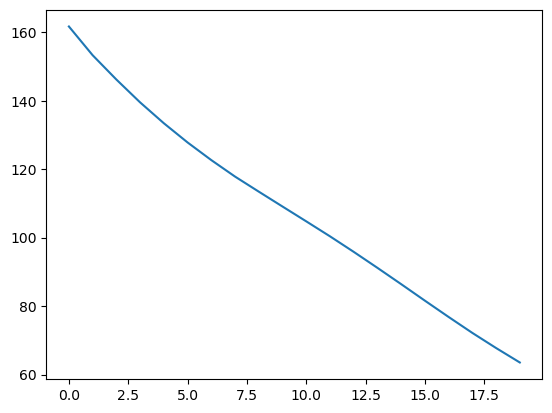

In [14]:
final_loss=train2(20, x_train, y_train, n)

In [15]:
def predict(x):

    logits = n(x)

    values = [v.data for v in logits]

    pred_class = values.index(max(values))

    return pred_class

class_names = {
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
}

true_class = y_test[0]
pred_class = predict(x_test[0])

print("True:", class_names[true_class])
print("Predicted:", class_names[pred_class])

True: Versicolor
Predicted: Versicolor


In [16]:
for x, y in zip(x_test[:5], y_test[:5]):

    pred = predict(x)

    print(
        f"True: {class_names[y]} | Predicted: {class_names[pred]}"
    )

True: Versicolor | Predicted: Versicolor
True: Setosa | Predicted: Setosa
True: Virginica | Predicted: Virginica
True: Versicolor | Predicted: Versicolor
True: Versicolor | Predicted: Versicolor


In [17]:
draw_dot(final_loss)

AttributeError: 'float' object has no attribute '_prev'

In [ ]:
draw_dot(ypred[0][0])